# Moran's Index for slope mean

In [ ]:
import pip
pip.main(['install','matplotlib-scalebar'])

In [2]:

import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sbn
import matplotlib
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import pysal
from pysal.explore import esda
from pysal.viz import splot
from pysal.lib import weights
from splot.esda import lisa_cluster
from splot.esda import plot_moran
from splot.esda import plot_local_autocorrelation, moran_scatterplot

import warnings
warnings.filterwarnings("ignore")

In [8]:
import sys
!{sys.executable} -m pip install "numpy<=2.2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 11.2 MB/s eta 0:00:00m eta 0:00:010:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6


### Catchments

In [3]:
cat=gpd.read_file("/home/edier/GoogleDrive/INVESTIGACION/PAPERS/ELABORACION/PAPER_SAR/Data/df_catchments_kmeans.gpkg")
cat.head(2)

,id,Nombre,ID_CUENCA,cuenca,area,elev_mean,elev_median,rel_mean,rel_median,rainfallAnnual_mean,...,slope_mean,kmeans,RainfallDaysmean,RainfallDaysmedian,landcovermedian,geomedian,lands_rec,kmeans4,knn5,geometry
0,1,Quebrada Guaco,606.0,Cauca,18443928,1615.334363,1607.0,510.665139,505.0,2264.807895,...,29.278027,C,1112.245024,1066.0,grass,sediment,4.0,D,B,"POLYGON ((454732.74 622820.251, 454684.825 622..."
1,2,Quebrada Cabaña,601.0,Cauca,15797104,1485.514279,1443.0,587.551540,590.0,2453.187233,...,27.276356,C,1381.331112,1416.0,grass,volcanic,6.0,D,B,"POLYGON ((445998.99 633523.601, 445938.99 6334..."


In [4]:
w_knn5 = weights.KNN.from_dataframe(cat, k=5)

In [5]:
cat['W_slope'] = weights.lag_spatial(w_knn5, cat['slope_mean'])

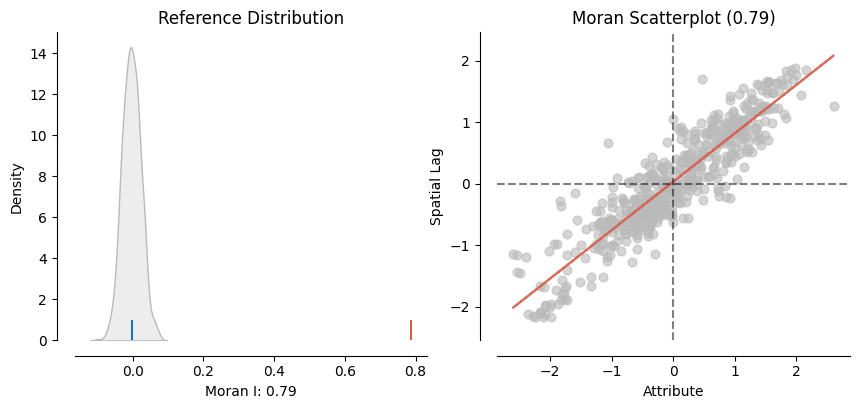

In [6]:
mi = esda.Moran(cat['slope_mean'], w_knn5)
plot_moran(mi);

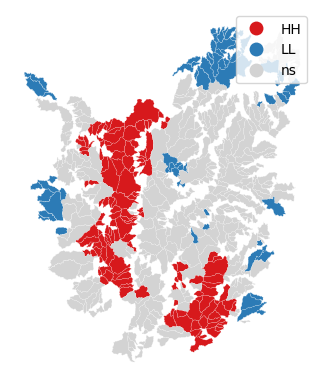

In [7]:
lisa = esda.Moran_Local(cat['slope_mean'], w_knn5)
lisa_cluster(lisa, cat);

<Axes: ylabel='Density'>

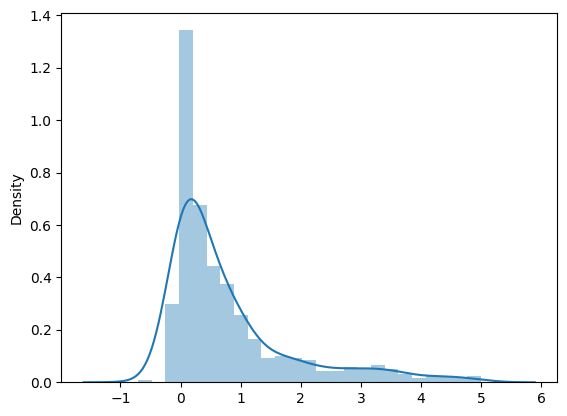

In [8]:
sbn.distplot(lisa.Is)

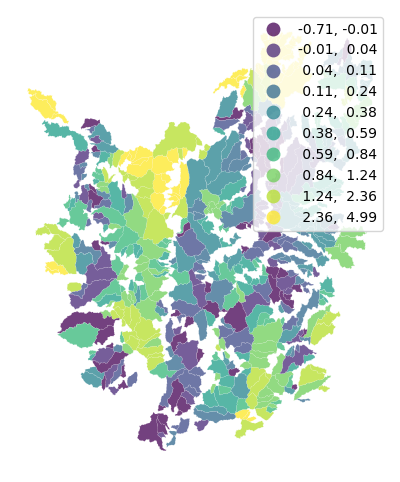

In [9]:
f, ax = plt.subplots(1, figsize=(6,6))
cat['Is'] = lisa.Is
cat.plot(column='Is', cmap='viridis', scheme='quantiles',k=10, edgecolor='white', linewidth=0.1, alpha=0.75, legend=True,ax=ax);
ax.set_axis_off()

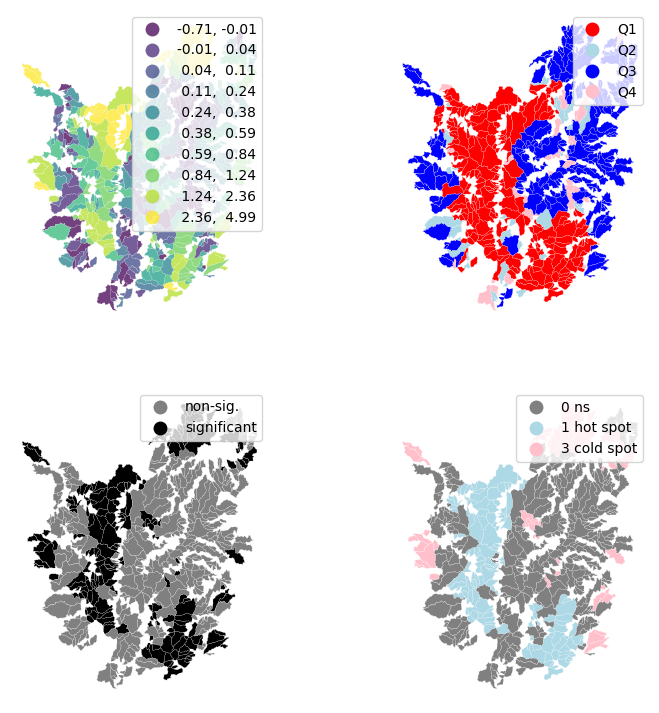

In [10]:
from matplotlib.colors import ListedColormap
f, axs = plt.subplots(nrows=2, ncols=2, figsize=(9, 9))
axs = axs.flatten()

# Subplot 1 #
ax = axs[0]
cat.plot(column='Is', cmap='viridis', scheme='quantiles', k=10, edgecolor='white', linewidth=0.1, alpha=0.75, legend=True, ax=ax)
ax.set_aspect('equal')
ax.set_axis_off()

# Subplot 2 #
ax = axs[1]
q_labels = ['Q1', 'Q2', 'Q3', 'Q4']
labels = [q_labels[i-1] for i in lisa.q]
hmap = ListedColormap([ 'red', 'lightblue', 'blue', 'pink'])
cat.assign(cl=labels).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax,edgecolor='white', legend=True)
ax.set_aspect('equal')
ax.set_axis_off()

# Subplot 3 #
ax = axs[2]
sig = 1 * (lisa.p_sim < 0.05)
hmap = ListedColormap(['grey','black'])
labels = ['non-sig.', 'significant'] 
labels = [labels[i] for i in sig]
cat.assign(cl=labels).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax,edgecolor='white', legend=True)
ax.set_aspect('equal')
ax.set_axis_off()
                            
# Subplot 4 #
ax = axs[3]
hotspot = 1 * (sig * lisa.q==1)
coldspot = 3 * (sig * lisa.q==3)
doughnut = 2 * (sig * lisa.q==2)
diamond = 4 * (sig * lisa.q==4)
spots = hotspot + coldspot + doughnut + diamond
spot_labels = [ '0 ns', '1 hot spot', '2 doughnut', '3 cold spot', '4 diamond']
labels = [spot_labels[i] for i in spots]
hmap = ListedColormap([ 'grey', 'red', 'lightblue', 'blue', 'pink'])
cat.assign(cl=labels).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax,edgecolor='white', legend=True)
ax.set_aspect('equal')
ax.set_axis_off()

plt.show()

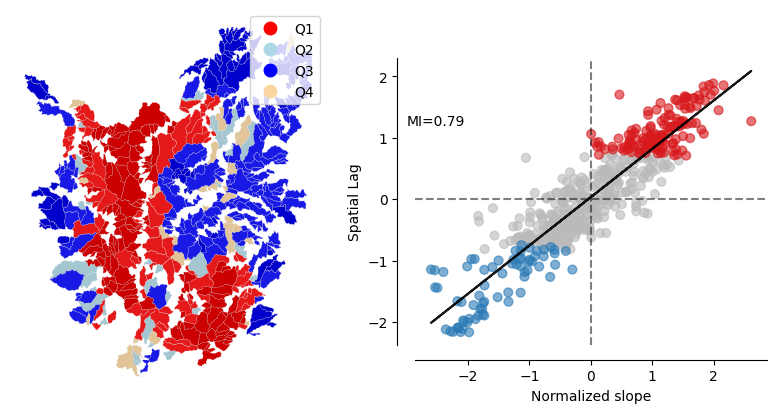

In [15]:
from matplotlib.colors import ListedColormap
f, ax = plt.subplots(nrows=1, ncols=2,figsize=(10,5))
axs = ax.flatten()

q_labels = ['Q1', 'Q2', 'Q3', 'Q4']
labels1 = [q_labels[i-1] for i in lisa.q]
hmap = ListedColormap([ 'red', 'lightblue', 'blue', '#FAD7A0'])
cat.assign(cl=labels1).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax[0],edgecolor='white', legend=True)

sig = 1 * (lisa.p_sim < 0.05)
hmap = ListedColormap(['grey','black'])
labels2 = ['non-sig.', 'significant'] 
labels2 = [labels2[i] for i in sig]
cat.assign(cl=labels2).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax[0],edgecolor='white', alpha=0.20)
ax[0].set_aspect('equal')
ax[0].set_axis_off()

moran_scatterplot(lisa, p=0.05,ax=ax[1])
ax[1].text(-3,1.2,f'MI={round(mi.I, 2)}')
ax[1].set_xlabel("Normalized slope")
ax[1].set_title('');
                            
plt.savefig('/home/edier/GoogleDrive/INVESTIGACION/PAPERS/ELABORACION/PAPER_SAR/Figures/figFinal/Fig6.png', dpi=500, bbox_inches='tight');

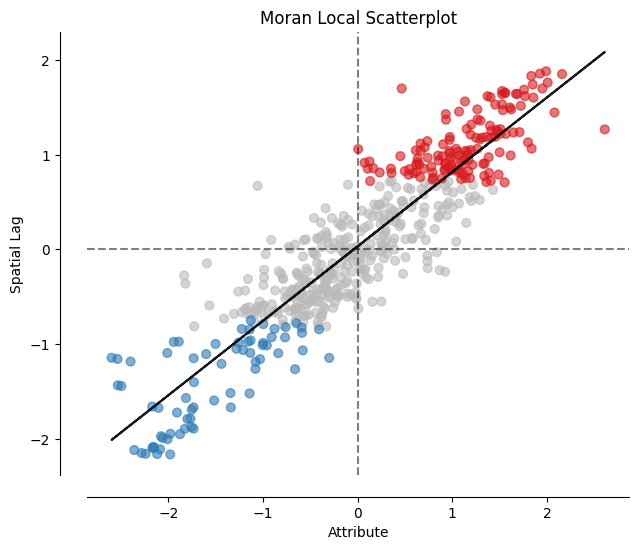

In [12]:
fig, ax = moran_scatterplot(lisa, p=0.05);

(<Figure size 1500x400 with 3 Axes>,
 array([<Axes: title={'center': 'Moran Local Scatterplot'}, xlabel='Attribute', ylabel='Spatial Lag'>,
        <Axes: >, <Axes: >], dtype=object))

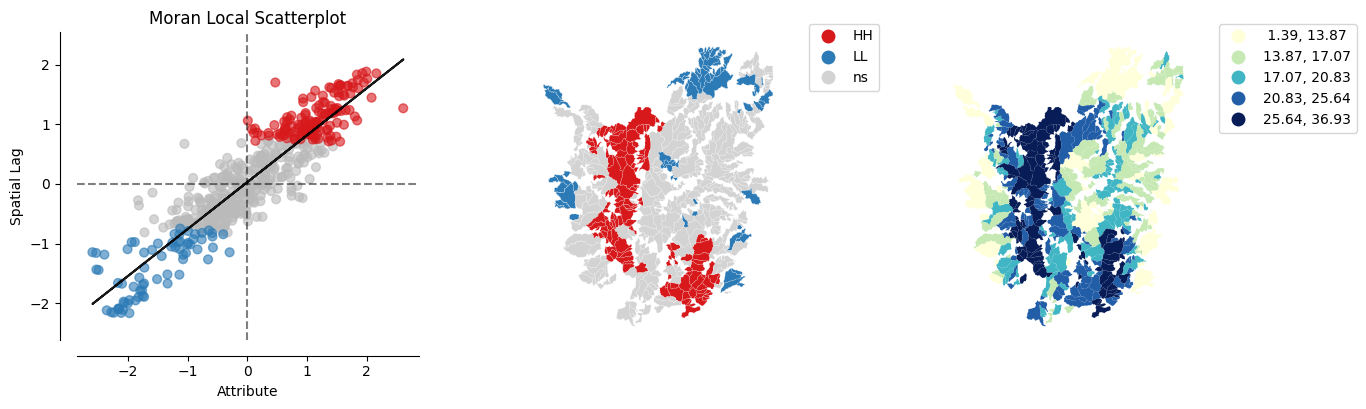

In [13]:
plot_local_autocorrelation(lisa, cat, 'slope_mean')

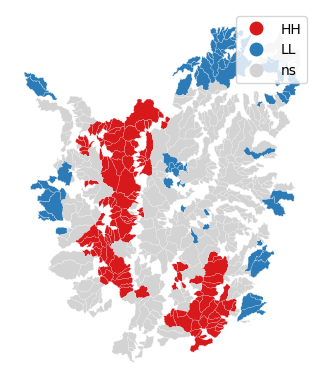

In [14]:
lisa_l = esda.Moran_Local(cat['slope_mean'], w_knn5)
lisa_cluster(lisa_l, cat);